In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\bharg\wind_power_forecasting\data\T1.csv')

In [3]:
# 1. Parse DateTime correctly
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%d %m %Y %H:%M')
df.set_index('Date/Time', inplace=True)
df.sort_index(inplace=True)

# Rename columns
df.rename(columns={
    'LV ActivePower (kW)': 'ActivePower',
    'Wind Speed (m/s)': 'WindSpeed',
    'Theoretical_Power_Curve (KWh)': 'TheoreticalPower',
    'Wind Direction (°)': 'WindDirection'
}, inplace=True)

print("✅ Data Loaded & Indexed")
print("Date Range:", df.index.min(), "-", df.index.max())
print("Total Records:", len(df))

✅ Data Loaded & Indexed
Date Range: 2018-01-01 00:00:00 - 2018-12-31 23:50:00
Total Records: 50530


In [4]:
# 2. Check Missing Values
print("\nMissing Values:\n", df.isnull().sum())

# 3. Handle Negative Power Values
print("\nNegative Power Values:", (df['ActivePower'] < 0).sum())
df['ActivePower'] = df['ActivePower'].clip(lower=0)   # Replace negatives with 0


Missing Values:
 ActivePower         0
WindSpeed           0
TheoreticalPower    0
WindDirection       0
dtype: int64

Negative Power Values: 57


In [5]:
# 4. Outlier Analysis (Wind Speed)
print("\nWind Speed Stats:")
print(df['WindSpeed'].describe())

# Optional: Remove unrealistic wind speeds (> 30 m/s)
df = df[df['WindSpeed'] <= 30]

# 5. Create Target and Basic Features
df['PowerDeviation'] = df['ActivePower'] - df['TheoreticalPower']   # Very useful feature

print("\n✅ Cleaning Completed!")
print(df.head())


Wind Speed Stats:
count    50530.000000
mean         7.557952
std          4.227166
min          0.000000
25%          4.201395
50%          7.104594
75%         10.300020
max         25.206011
Name: WindSpeed, dtype: float64

✅ Cleaning Completed!
                     ActivePower  WindSpeed  TheoreticalPower  WindDirection  \
Date/Time                                                                      
2018-01-01 00:00:00   380.047791   5.311336        416.328908     259.994904   
2018-01-01 00:10:00   453.769196   5.672167        519.917511     268.641113   
2018-01-01 00:20:00   306.376587   5.216037        390.900016     272.564789   
2018-01-01 00:30:00   419.645905   5.659674        516.127569     271.258087   
2018-01-01 00:40:00   380.650696   5.577941        491.702972     265.674286   

                     PowerDeviation  
Date/Time                            
2018-01-01 00:00:00      -36.281117  
2018-01-01 00:10:00      -66.148316  
2018-01-01 00:20:00      -84.523429  

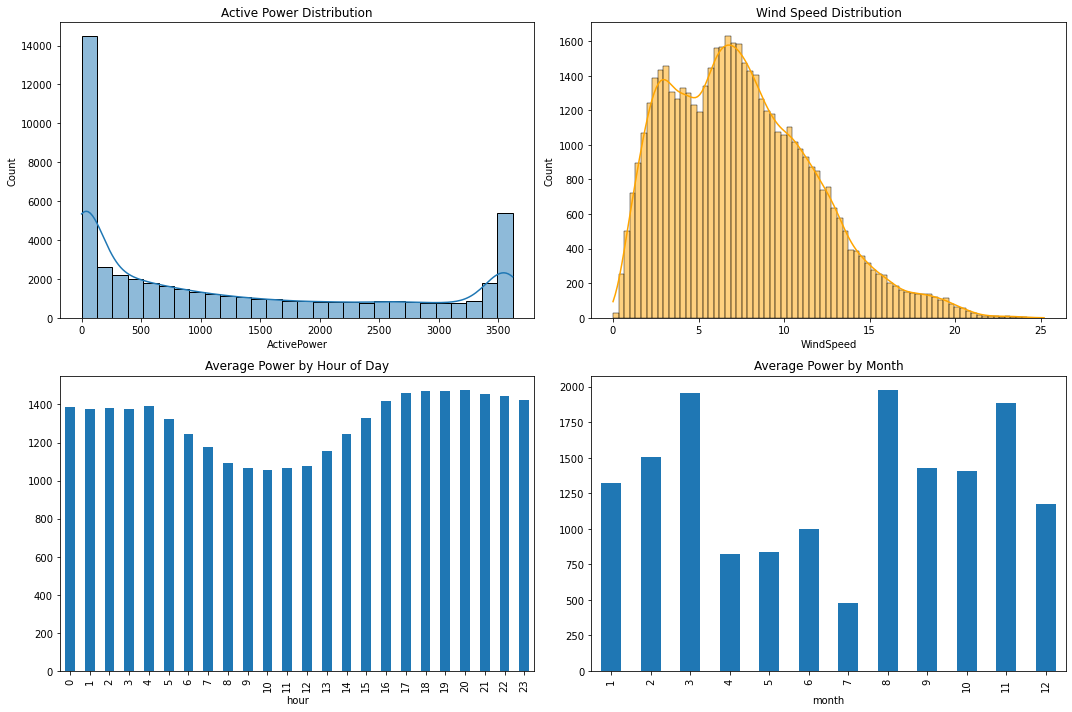

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# 1. Power Distribution
sns.histplot(df['ActivePower'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Active Power Distribution')

# 2. Wind Speed Distribution
sns.histplot(df['WindSpeed'], kde=True, ax=axes[0,1], color='orange')
axes[0,1].set_title('Wind Speed Distribution')

# 3. Hourly Pattern
df['hour'] = df.index.hour
hourly_power = df.groupby('hour')['ActivePower'].mean()
hourly_power.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Average Power by Hour of Day')

# 4. Monthly Pattern
df['month'] = df.index.month
monthly_power = df.groupby('month')['ActivePower'].mean()
monthly_power.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Average Power by Month')

plt.tight_layout()
plt.show()

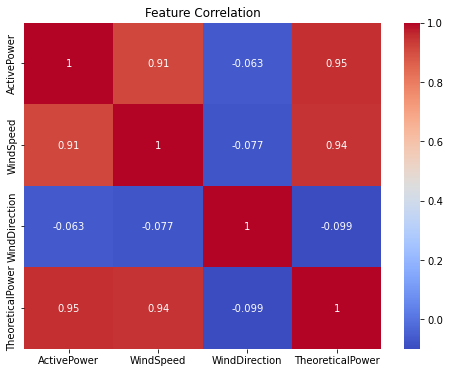

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['ActivePower', 'WindSpeed', 'WindDirection', 'TheoreticalPower']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()